* import library

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import joblib

* load csv

In [2]:
df = pd.read_csv('ecommerce_churn_data.csv')

In [3]:
df['Complain'].value_counts()

Complain
0    7998
1    2207
Name: count, dtype: int64

In [4]:
df['Churn'].value_counts()

Churn
0    7769
1    2436
Name: count, dtype: int64

In [5]:
pd.crosstab(df['Complain'], df['Churn'])

Churn,0,1
Complain,,
0,7703,295
1,66,2141


* Analyze data

In [6]:
df.sample(3)

,CustomerID,Age,Gender,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
4354,4356,52,Male,43.0,Desktop,2,19.0,4.2,4,2,3,1,30,10,290.0,1
1797,56384,30,Male,12.0,Mobile,3,2.5,3.5,3,4,1,0,17,4,135.0,0
8748,8750,28,Female,6.0,Desktop,1,5.2,1.5,2,2,1,1,3,20,30.5,1


* Get detailed information about the dataset including:
- Number of entries (rows)
- Column names and data types
- Non-null value counts (to identify missing data)
- Memory usage

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10205 entries, 0 to 10204
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 10205 non-null  int64  
 1   Age                        10205 non-null  int64  
 2   Gender                     10205 non-null  object 
 3   Tenure                     10204 non-null  float64
 4   PreferredLoginDevice       10205 non-null  object 
 5   CityTier                   10205 non-null  int64  
 6   WarehouseToHome            10205 non-null  float64
 7   HoursSpentOnApp            10205 non-null  float64
 8   NumberOfDevicesRegistered  10205 non-null  int64  
 9   SatisfactionScore          10205 non-null  int64  
 10  NumberOfAddress            10205 non-null  int64  
 11  Complain                   10205 non-null  int64  
 12  OrderCount                 10205 non-null  int64  
 13  DaySinceLastOrder          10205 non-null  int

* Descriptive Statistics

In [8]:
df.describe()

,CustomerID,Age,Tenure,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
count,10205.000000,10205.000000,10204.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000,10205.000000
mean,29677.581872,35.193043,19.685515,2.007349,9.887428,3.343626,2.833807,3.504459,1.861832,0.216267,21.453895,8.891720,157.953214,0.238707
std,25617.824693,9.625432,14.475853,0.826741,5.481747,1.133353,0.921249,1.162892,0.920454,0.411718,18.955878,8.283807,107.627670,0.426314
min,307.000000,18.000000,1.000000,1.000000,0.500000,0.800000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5097.000000,28.000000,8.000000,1.000000,6.000000,2.500000,2.000000,3.000000,1.000000,0.000000,9.000000,3.000000,75.000000,0.000000
50%,9711.000000,33.000000,16.000000,2.000000,9.000000,3.400000,3.000000,4.000000,2.000000,0.000000,18.000000,6.000000,140.000000,0.000000
75%,56429.000000,42.000000,28.000000,3.000000,13.000000,4.100000,3.000000,4.000000,2.000000,0.000000,28.000000,12.000000,220.000000,0.000000
max,56760.000000,65.000000,85.000000,3.000000,35.000000,8.500000,5.000000,5.000000,5.000000,1.000000,250.000000,60.000000,1120.000000,1.000000


* Checking for Null Values

In [9]:
print(df.isnull().sum())

CustomerID                   0
Age                          0
Gender                       0
Tenure                       1
PreferredLoginDevice         0
CityTier                     0
WarehouseToHome              0
HoursSpentOnApp              0
NumberOfDevicesRegistered    0
SatisfactionScore            0
NumberOfAddress              0
Complain                     0
OrderCount                   0
DaySinceLastOrder            0
CashbackAmount               0
Churn                        0
dtype: int64


* Inspect null rows

In [10]:
print(df[df['Tenure'].isnull()])

      CustomerID  Age  Gender  Tenure PreferredLoginDevice  CityTier  \
4424        4426   24  Female     NaN              Desktop         2   

      WarehouseToHome  HoursSpentOnApp  NumberOfDevicesRegistered  \
4424              3.0              1.3                          2   

      SatisfactionScore  NumberOfAddress  Complain  OrderCount  \
4424                  5                1         0           7   

      DaySinceLastOrder  CashbackAmount  Churn  
4424                  2            60.0      0  


* Handle Missing Values

In [11]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
CustomerID                   0
Age                          0
Gender                       0
Tenure                       0
PreferredLoginDevice         0
CityTier                     0
WarehouseToHome              0
HoursSpentOnApp              0
NumberOfDevicesRegistered    0
SatisfactionScore            0
NumberOfAddress              0
Complain                     0
OrderCount                   0
DaySinceLastOrder            0
CashbackAmount               0
Churn                        0
dtype: int64


* Check for Duplicates

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


* Basic EDA - Churn Distribution (Countplot)

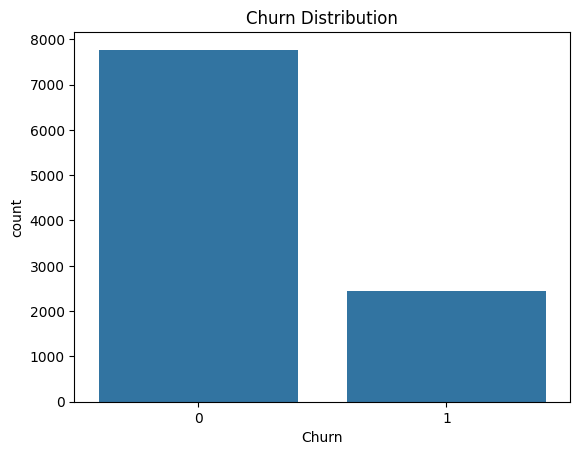

Churn
0    7769
1    2436
Name: count, dtype: int64


In [13]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn'].value_counts())

* head map

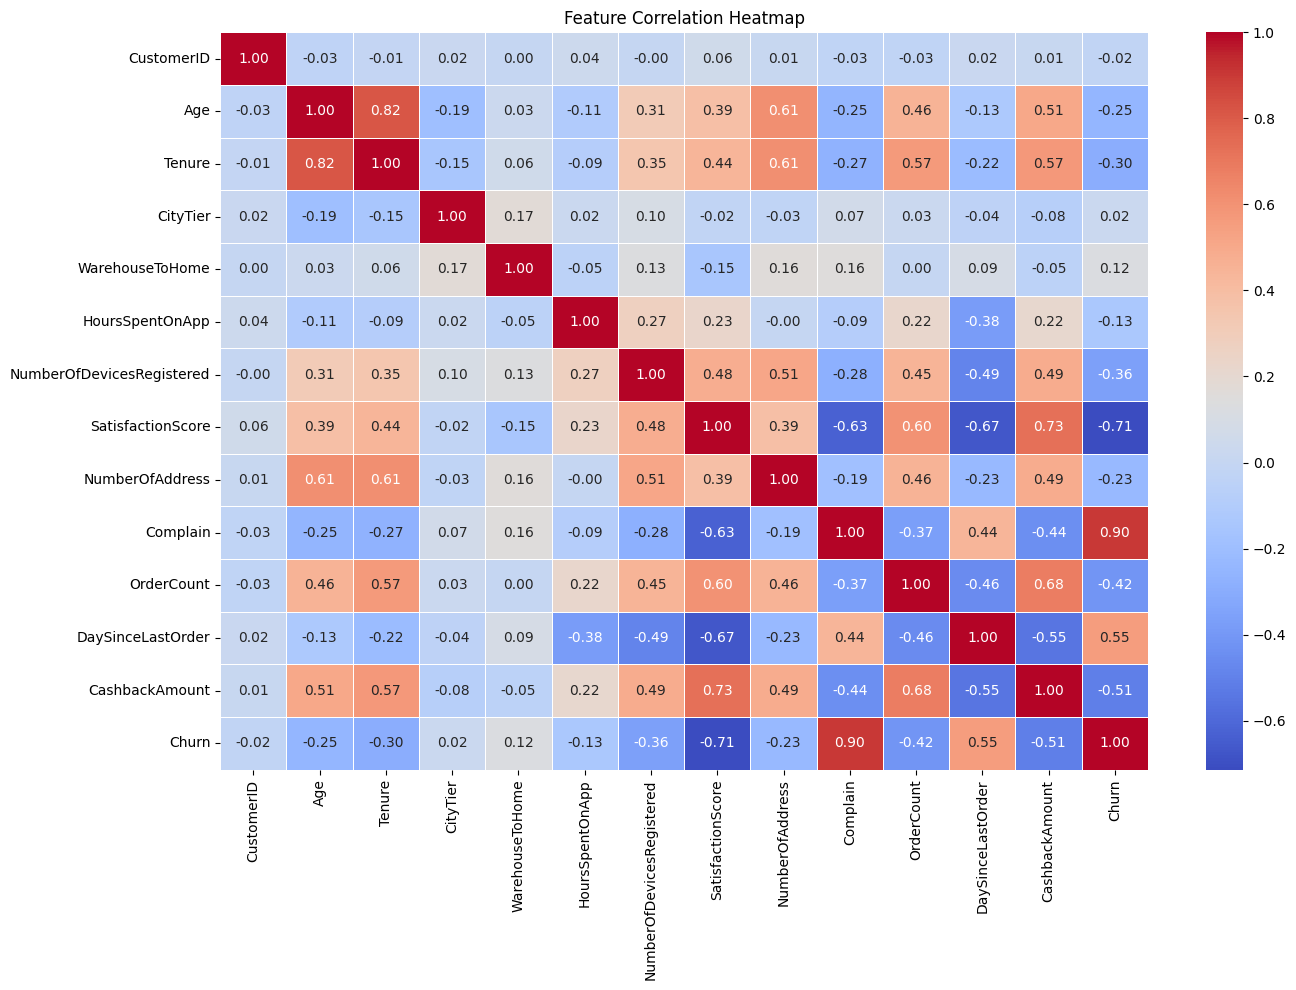

In [14]:
plt.figure(figsize=(14, 10))
# FIX: Only use numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

* Drop CustomerID

In [15]:
df = df.drop('CustomerID', axis=1)

*  Separate Features and Target

In [16]:
x = df.drop('Churn', axis=1)
y = df['Churn']

* Identify Column Types

In [17]:
cat_cols = x.select_dtypes(include='object').columns
num_cols = x.select_dtypes(exclude='object').columns
print("Categorical columns:", list(cat_cols))
print("Numerical columns:", list(num_cols))

Categorical columns: ['Gender', 'PreferredLoginDevice']
Numerical columns: ['Age', 'Tenure', 'CityTier', 'WarehouseToHome', 'HoursSpentOnApp', 'NumberOfDevicesRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


*  Train-Test Split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # FIX: ensures proportional churn/non-churn in train and test
)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

x_train shape: (8164, 14)
x_test shape: (2041, 14)
y_train shape: (8164,)
y_test shape: (2041,)

Train class distribution:
Churn
0    0.761269
1    0.238731
Name: proportion, dtype: float64

Test class distribution:
Churn
0    0.761391
1    0.238609
Name: proportion, dtype: float64


* Preprocessing using ColumnTransformer
1. OneHotEncoding -> convert categorical data into numeric
2. StandardScaler -> scaling numeric features

In [19]:
preprocessing = ColumnTransformer(
    transformers=[
        ('categorial', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first'), cat_cols),
        ('numerical', StandardScaler(), num_cols)
    ]
)

* Apply Preprocessing

In [20]:
X_train_processed = preprocessing.fit_transform(x_train)
X_test_processed = preprocessing.transform(x_test)

* See Columns After ColumnTransformer

In [21]:
cat_encoded = preprocessing.named_transformers_['categorial'].get_feature_names_out(cat_cols)
all_columns = np.concatenate([cat_encoded, num_cols])
print("All columns after preprocessing:")
print(all_columns)

All columns after preprocessing:
['Gender_Male' 'Gender_Other' 'PreferredLoginDevice_Mobile' 'Age' 'Tenure'
 'CityTier' 'WarehouseToHome' 'HoursSpentOnApp'
 'NumberOfDevicesRegistered' 'SatisfactionScore' 'NumberOfAddress'
 'Complain' 'OrderCount' 'DaySinceLastOrder' 'CashbackAmount']


* Convert to DataFrame

In [22]:
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_columns)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_columns)

clustering_features = ['OrderCount', 'DaySinceLastOrder']

X_train_processed_df.head()

,Gender_Male,Gender_Other,PreferredLoginDevice_Mobile,Age,Tenure,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount
0,0.0,0.0,0.0,-0.952060,-0.525463,-0.013938,-0.161369,-0.302492,0.176928,-0.437665,-0.934657,-0.523291,-0.660822,0.017735,-0.581776
1,1.0,0.0,0.0,-0.743947,-0.387427,-0.013938,-0.489406,-0.037680,0.176928,-0.437665,-0.934657,-0.523291,0.464097,0.745915,-1.016399
2,1.0,0.0,1.0,-0.327720,-0.249391,-1.224503,1.752181,0.050590,1.262159,-0.437665,0.149226,-0.523291,-0.660822,-0.224992,0.948650
3,0.0,0.0,0.0,-1.264230,-0.870553,-0.013938,2.025545,-0.920387,-1.993533,-1.299069,-0.934657,1.910982,-0.821525,2.445001,-0.951668
4,0.0,0.0,1.0,-1.368287,-1.284661,-1.224503,-1.218377,1.462920,-1.993533,-1.299069,-0.934657,-0.523291,-0.982228,0.260461,-1.044141


*  Extract Clustering Features

In [23]:
X_train_cluster = X_train_processed_df[clustering_features]
X_test_cluster = X_test_processed_df[clustering_features]

*  KMeans - Decide K Using Elbow Method

In [24]:
wcss = []
for i in range(1, 8):
    kmeans_temp = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_temp.fit(X_train_cluster)
    wcss.append(kmeans_temp.inertia_)

* Plot Elbow Graph

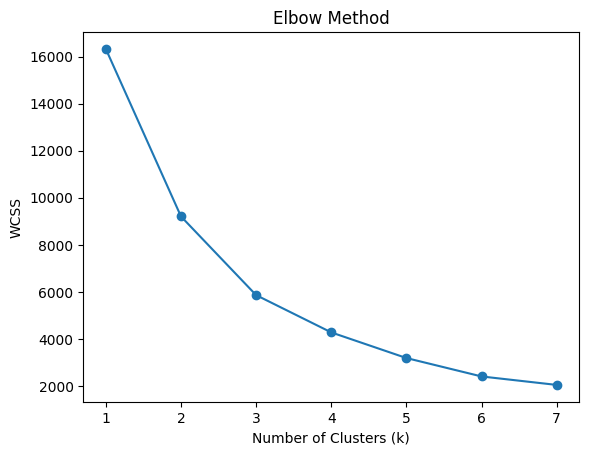

In [25]:
plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

* Train KMeans Model (k=3 chosen from elbow)

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(X_train_cluster)
test_clusters = kmeans.predict(X_test_cluster)

print("Unique clusters:", np.unique(train_clusters))

Unique clusters: [0 1 2]


* Checking Clustering Performance (Silhouette Score)

In [27]:
score = silhouette_score(X_train_cluster, train_clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5077209590121222


*  Visualize Clusters

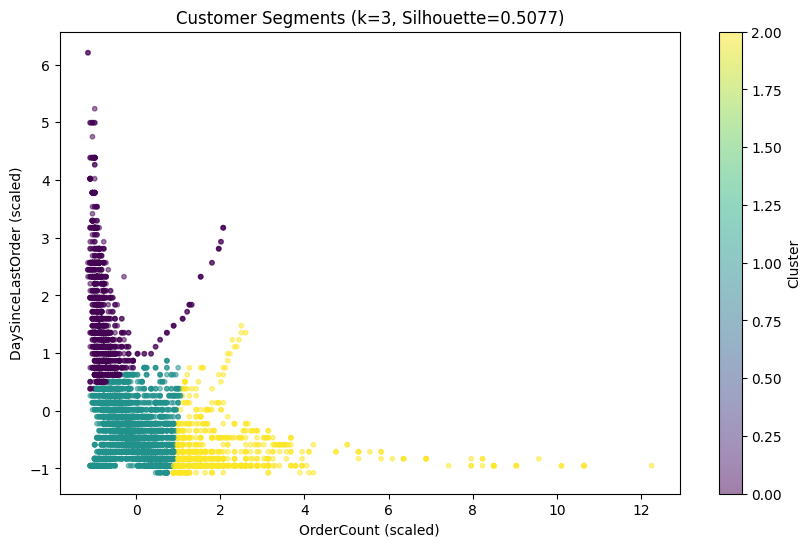

In [28]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    X_train_cluster['OrderCount'],
    X_train_cluster['DaySinceLastOrder'],
    c=train_clusters, cmap='viridis', alpha=0.5, s=10
)
plt.xlabel('OrderCount (scaled)')
plt.ylabel('DaySinceLastOrder (scaled)')
plt.title(f'Customer Segments (k=3, Silhouette={score:.4f})')
plt.colorbar(scatter, label='Cluster')
plt.show()

* Add Cluster Labels as New Feature

In [29]:
X_train_final = X_train_processed_df.copy()
X_test_final = X_test_processed_df.copy()

X_train_final['Cluster'] = train_clusters
X_test_final['Cluster'] = test_clusters

print('Train shape with clusters:', X_train_final.shape)
print('Test shape with clusters:', X_test_final.shape)
X_train_final.head()

Train shape with clusters: (8164, 16)
Test shape with clusters: (2041, 16)


,Gender_Male,Gender_Other,PreferredLoginDevice_Mobile,Age,Tenure,CityTier,WarehouseToHome,HoursSpentOnApp,NumberOfDevicesRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderCount,DaySinceLastOrder,CashbackAmount,Cluster
0,0.0,0.0,0.0,-0.952060,-0.525463,-0.013938,-0.161369,-0.302492,0.176928,-0.437665,-0.934657,-0.523291,-0.660822,0.017735,-0.581776,1
1,1.0,0.0,0.0,-0.743947,-0.387427,-0.013938,-0.489406,-0.037680,0.176928,-0.437665,-0.934657,-0.523291,0.464097,0.745915,-1.016399,1
2,1.0,0.0,1.0,-0.327720,-0.249391,-1.224503,1.752181,0.050590,1.262159,-0.437665,0.149226,-0.523291,-0.660822,-0.224992,0.948650,1
3,0.0,0.0,0.0,-1.264230,-0.870553,-0.013938,2.025545,-0.920387,-1.993533,-1.299069,-0.934657,1.910982,-0.821525,2.445001,-0.951668,0
4,0.0,0.0,1.0,-1.368287,-1.284661,-1.224503,-1.218377,1.462920,-1.993533,-1.299069,-0.934657,-0.523291,-0.982228,0.260461,-1.044141,1


* Handle Class Imbalance with SMOTE

In [30]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', pd.Series(y_train_balanced).value_counts().to_dict())

Before SMOTE: {0: 6215, 1: 1949}
After SMOTE: {0: 6215, 1: 6215}


* Train Random Forest Classifier

In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
print('Model trained successfully!')

Model trained successfully!


* Cross-Validation for More Reliable Evaluation

In [32]:
cv_scores = cross_val_score(rf_model, X_train_balanced, y_train_balanced, cv=5, scoring='f1')
print("Cross-Validation F1 Scores:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())
print("Std F1 Score:", cv_scores.std())

Cross-Validation F1 Scores: [0.99677419 0.99718536 0.99759036 0.99799277 0.99959791]
Mean F1 Score: 0.9978281204000448
Std F1 Score: 0.0009736210762387827


* Predict on Test Set and Evaluate

In [33]:
y_pred = rf_model.predict(X_test_final)

print('Accuracy:', accuracy_score(y_test, y_pred))
print()
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))
print()
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9990200881920627

Confusion Matrix:
[[1553    1]
 [   1  486]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1554
           1       1.00      1.00      1.00       487

    accuracy                           1.00      2041
   macro avg       1.00      1.00      1.00      2041
weighted avg       1.00      1.00      1.00      2041



* Save Models (using joblib — recommended for sklearn)

In [34]:
joblib.dump(rf_model, 'churn_rf_model.pkl')
joblib.dump(kmeans, 'churn_kmeans.pkl')
joblib.dump(preprocessing, 'churn_preprocessing.pkl')

print("All models saved successfully!")

All models saved successfully!


* Predict for a New Customer (Demo)

In [35]:
new_customer = pd.DataFrame({
    'Gender': ['Male'],
    'PreferredLoginDevice': ['Mobile'],
    'Age': [30],
    'Tenure': [12],
    'CityTier': [1],
    'WarehouseToHome': [15],
    'HoursSpentOnApp': [3],
    'NumberOfDevicesRegistered': [2],
    'SatisfactionScore': [4],
    'NumberOfAddress': [2],
    'Complain': [0],
    'OrderCount': [5],
    'DaySinceLastOrder': [10],
    'CashbackAmount': [120]
})

* Step 1: Preprocess

In [36]:
new_processed = preprocessing.transform(new_customer)
new_processed_df = pd.DataFrame(new_processed, columns=all_columns)

* Step 2: Clustering

In [37]:
cluster_features = new_processed_df[['OrderCount', 'DaySinceLastOrder']]
new_cluster = kmeans.predict(cluster_features)

* Step 3: Add cluster column

In [38]:
new_processed_df['Cluster'] = new_cluster
print("\nAssigned Cluster:", new_cluster[0])


Assigned Cluster: 1


* Step 4: Predict churn

In [39]:
prediction = rf_model.predict(new_processed_df)

if prediction[0] == 1:
    print("\nPrediction: Customer WILL CHURN")
else:
    print("\nPrediction: Customer will STAY")


Prediction: Customer will STAY


python -m streamlit run dashboard.py